In [1]:
import os

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

import agent_k.config.general as config_general
from agent_k.config.logger import logger
from agent_k.config.schemas import DataSource, MinModHyperCols

df_hyper = pd.read_csv(
    os.path.join(
        config_general.GROUND_TRUTH_DIR,
        config_general.enriched_hyper_reponse_file(config_general.COMMODITY),
    )
)

# Filter the hyper dataframe to only include 43-101 data
df_hyper = df_hyper[
    df_hyper[MinModHyperCols.DATA_SOURCE.value].isin([DataSource.API_CDR_LAND.value])
]
logger.info(f"Hyper dataframe filtered to {len(df_hyper)} rows")
df_hyper.head()

2025-02-27 20:40:59.666 | INFO     | __main__:<module>:27 - Hyper dataframe filtered to 346 rows


,mineral_site_uri,mineral_site_name,mineral_site_type,mineral_site_rank,sites,country,state_or_province,latitude,longitude,top_1_deposit_type,top_1_deposit_group,top_1_deposit_environment,top_1_deposit_classification_confidence,top_1_deposit_classification_source,total_grade,total_tonnage,data_source,record_value,downloaded_pdf
118,https://minmod.isi.edu/derived/dedup_site__api...,Windy Lake Property,NotSpecified,NaN,site__api-cdr-land-v1-docs-documents__02aadf03...,Canada,Ontario,46.522100,-81.176300,Unknown,Ultramafic and (or) mafic-layered intrusion,Magmatic,0.883629,"algorithm predictions, SRI deposit type classi...",NaN,NaN,43-101,02aadf0391e322c81149c2bc4ff657e65673e42d7df09e...,True
121,https://minmod.isi.edu/derived/dedup_site__api...,Shining Tree,NotSpecified,NaN,site__api-cdr-land-v1-docs-documents__02a000a8...,Canada,Ontario,46.200000,-81.800000,Komatiite nickel-copper-PGE,Komatiite,Magmatic,0.899732,"algorithm predictions, SRI deposit type classi...",0.686255,2.51,43-101,02a000a83e76360bec8f3fce2ff46cc8099f950cc1f757...,True
305,https://minmod.isi.edu/derived/dedup_site__api...,Wolf Mountain Property,NotSpecified,NaN,site__api-cdr-land-v1-docs-documents__021a7946...,Canada,Ontario,49.030000,-88.950000,Unknown,Ultramafic and (or) mafic-layered intrusion,Magmatic,0.881482,"algorithm predictions, SRI deposit type classi...",NaN,NaN,43-101,021a794659a5c972b322e3bda39a1740793bb55223899e...,True
306,https://minmod.isi.edu/derived/dedup_site__api...,Thierry and K1 -1 Cu -Ni-PGE Deposits,NotSpecified,NaN,site__api-cdr-land-v1-docs-documents__026636cb...,Canada,Ontario,51.497583,-90.347908,Unknown,Komatiite,Magmatic,0.900000,"algorithm predictions, SRI deposit type classi...",NaN,NaN,43-101,026636cb7032ea2359a8ede9e693e70e0d24b4344ed2d3...,True
324,https://minmod.isi.edu/derived/dedup_site__api...,MARATHON PGM-CU PROPERTY,NotSpecified,NaN,site__api-cdr-land-v1-docs-documents__024cd226...,Canada,NaN,48.373400,-89.133400,Unknown,Ultramafic and (or) mafic-layered intrusion,Magmatic,1.000000,Inferlink Extraction v3,NaN,NaN,43-101,024cd2265b54462f7bc8dce7e05a64a1042f66d2bcf9f5...,True


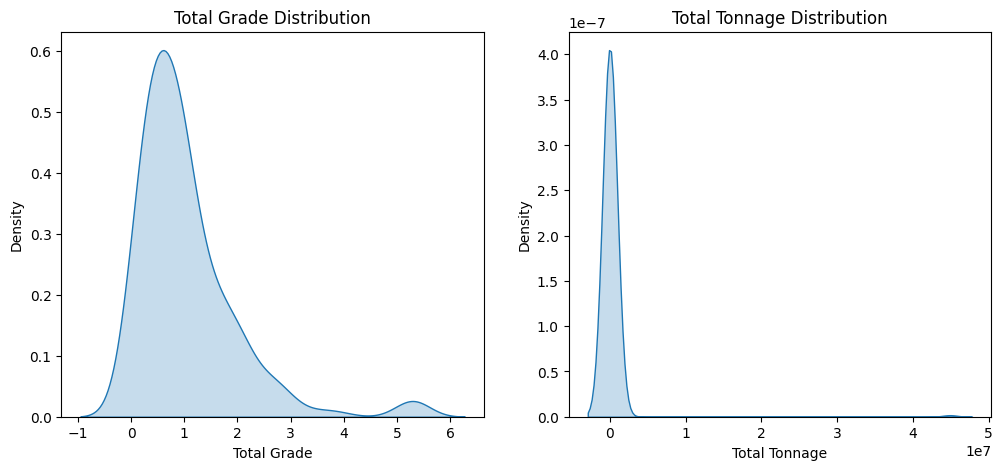

In [2]:
# Plot the kernel density estimate of the total grade and total tonnage side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
sns.kdeplot(df_hyper[MinModHyperCols.TOTAL_GRADE.value], fill=True, ax=ax1)
sns.kdeplot(df_hyper[MinModHyperCols.TOTAL_TONNAGE.value], fill=True, ax=ax2)
# Add title and labels
ax1.set_title("Total Grade Distribution")
ax2.set_title("Total Tonnage Distribution")
ax1.set_xlabel("Total Grade")
ax2.set_xlabel("Total Tonnage")
plt.show()

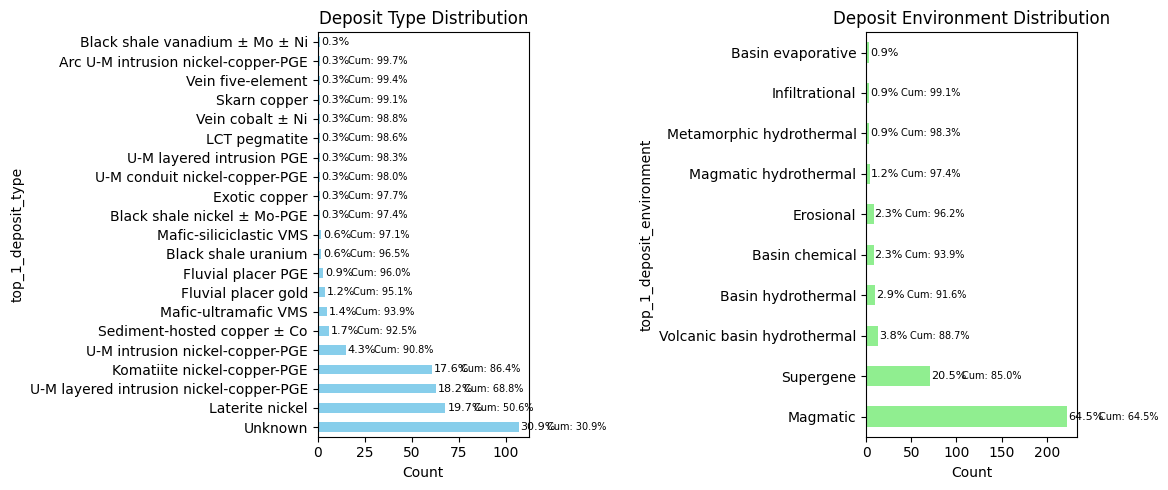

In [3]:
# Plot the distribution of the top 1 deposit type and deposit environment side by side
# Get value counts and percentages for deposit type
deposit_type_counts = df_hyper[MinModHyperCols.TOP_1_DEPOSIT_TYPE.value].value_counts(
    ascending=False
)
deposit_type_pcts = deposit_type_counts / len(df_hyper) * 100

# Get value counts and percentages for deposit environment
deposit_env_counts = df_hyper[
    MinModHyperCols.TOP_1_DEPOSIT_ENVIRONMENT.value
].value_counts(ascending=False)
deposit_env_pcts = deposit_env_counts / len(df_hyper) * 100

# Create figure with 1x2 subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot deposit type counts as horizontal bars
deposit_type_counts.plot(kind="barh", ax=ax1, color="skyblue")
ax1.set_xlabel("Count")
ax1.set_title("Deposit Type Distribution")

# Add percentage labels to the right of the bars for deposit type
cumulative_pct = 0
for i, (count, pct) in enumerate(
    zip(deposit_type_counts, deposit_type_pcts, strict=False)
):
    ax1.text(count + 1, i, f"{pct:.1f}%", va="center", fontsize=8)
    cumulative_pct += pct
    if i < len(deposit_type_counts) - 1:  # Skip the last one to avoid clutter
        ax1.text(count + 15, i, f"Cum: {cumulative_pct:.1f}%", va="center", fontsize=7)

# Plot deposit environment counts as horizontal bars
deposit_env_counts.plot(kind="barh", ax=ax2, color="lightgreen")
ax2.set_xlabel("Count")
ax2.set_title("Deposit Environment Distribution")

# Add percentage labels to the right of the bars for deposit environment
cumulative_pct = 0
for i, (count, pct) in enumerate(
    zip(deposit_env_counts, deposit_env_pcts, strict=False)
):
    ax2.text(count + 1, i, f"{pct:.1f}%", va="center", fontsize=8)
    cumulative_pct += pct
    if i < len(deposit_env_counts) - 1:  # Skip the last one to avoid clutter
        ax2.text(count + 35, i, f"Cum: {cumulative_pct:.1f}%", va="center", fontsize=7)

# Adjust layout
plt.tight_layout()
plt.show()

In [4]:
# When filtering outliers by using the 5th and 95th quantiles, it’s generally not recommended to fill missing values (NaNs) with 0 automatically.
before_count = len(df_hyper)
# Remove outliers from the total tonnage below 5th and above 95th percentile
lower_bound = df_hyper[MinModHyperCols.TOTAL_TONNAGE.value].quantile(0.05)
upper_bound = df_hyper[MinModHyperCols.TOTAL_TONNAGE.value].quantile(0.95)
df_hyper = df_hyper[
    (df_hyper[MinModHyperCols.TOTAL_TONNAGE.value] >= lower_bound)
    & (df_hyper[MinModHyperCols.TOTAL_TONNAGE.value] <= upper_bound)
]
after_count = len(df_hyper)
logger.info(f"Hyper dataframe filtered to {len(df_hyper)} rows")
logger.info(f"Removed {before_count - after_count} rows")
logger.info(
    f"Removed {round((before_count - after_count) / before_count * 100, 2)}% of the data"
)

2025-02-27 20:41:00.194 | INFO     | __main__:<module>:11 - Hyper dataframe filtered to 218 rows
2025-02-27 20:41:00.195 | INFO     | __main__:<module>:12 - Removed 128 rows
2025-02-27 20:41:00.195 | INFO     | __main__:<module>:13 - Removed 36.99% of the data


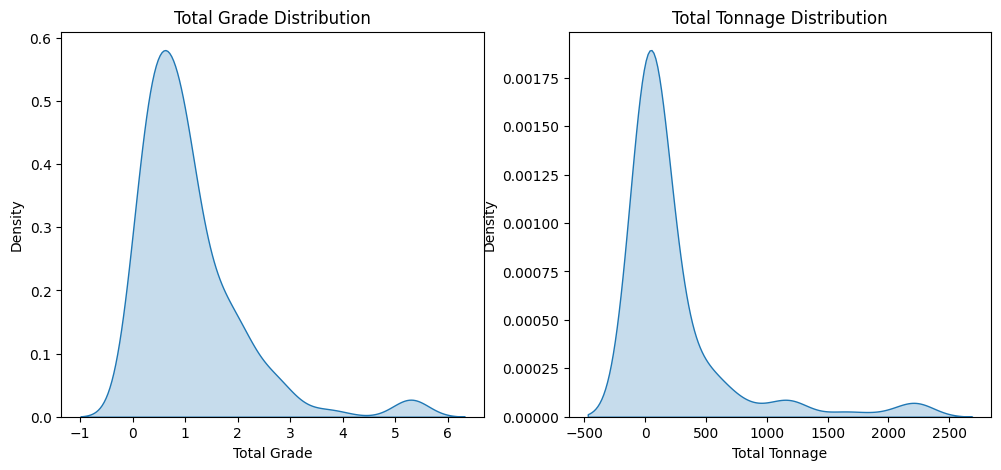

In [5]:
# Plot the kernel density estimate of the total grade and total tonnage side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
sns.kdeplot(df_hyper[MinModHyperCols.TOTAL_GRADE.value], fill=True, ax=ax1)
sns.kdeplot(df_hyper[MinModHyperCols.TOTAL_TONNAGE.value], fill=True, ax=ax2)
# Add title and labels
ax1.set_title("Total Grade Distribution")
ax2.set_title("Total Tonnage Distribution")
ax1.set_xlabel("Total Grade")
ax2.set_xlabel("Total Tonnage")
plt.show()

In [6]:
# Replace "Unknown" with "Not Found"
df_hyper[MinModHyperCols.TOP_1_DEPOSIT_TYPE.value] = df_hyper[
    MinModHyperCols.TOP_1_DEPOSIT_TYPE.value
].replace("Unknown", "Not Found")
df_hyper[MinModHyperCols.TOP_1_DEPOSIT_ENVIRONMENT.value] = df_hyper[
    MinModHyperCols.TOP_1_DEPOSIT_ENVIRONMENT.value
].replace("Unknown", "Not Found")

# Replace nan with "Not Found" for country, state and province
df_hyper[MinModHyperCols.COUNTRY.value] = df_hyper[
    MinModHyperCols.COUNTRY.value
].fillna("Not Found")
df_hyper[MinModHyperCols.STATE_OR_PROVINCE.value] = df_hyper[
    MinModHyperCols.STATE_OR_PROVINCE.value
].fillna("Not Found")
df_hyper[MinModHyperCols.MINERAL_SITE_NAME.value] = df_hyper[
    MinModHyperCols.MINERAL_SITE_NAME.value
].fillna("Not Found")

# Replace nan with 0 for total grade and total tonnage
df_hyper[MinModHyperCols.TOTAL_GRADE.value] = df_hyper[
    MinModHyperCols.TOTAL_GRADE.value
].fillna(0)
df_hyper[MinModHyperCols.TOTAL_TONNAGE.value] = df_hyper[
    MinModHyperCols.TOTAL_TONNAGE.value
].fillna(0)

In [7]:
# Save the filtered dataframe to a csv file
logger.info("Saving the filtered dataframe to a csv file")
logger.info(f"{len(df_hyper)} rows")
df_hyper.to_csv(
    os.path.join(
        config_general.GROUND_TRUTH_DIR,
        "minmod_hyper_response_enriched_nickel_subset_43_101_gt.csv",
    ),
    index=False,
)

2025-02-27 20:41:00.398 | INFO     | __main__:<module>:2 - Saving the filtered dataframe to a csv file
2025-02-27 20:41:00.400 | INFO     | __main__:<module>:3 - 218 rows
